# <span style="color:purple"> Radiative Effect & Forcing Calculations Following Ghan Methodology :


<span style="color:#fc8d62"><b>direct aerosol forcing</b></span> = (FSNTOA_dataset1 - FSNTOA_d2_dataset1) - (FSNTOA_dataset2 - FSNTOA_d2_dataset2)

<span style="color:#8da0cb"><b>cloud_aerosol_forcing</b></span> = (FSNTOA_d2_dataset1 - FSNTOAC_d2_dataset1) - (FSNTOA_d2_dataset2 - FSNTOAC_d2_dataset2)

<span style="color:#66c2a5"><b>surface_albedo_forcing</b></span> = FSNTOAC_d2_dataset1 - FSNTOAC_d2_dataset2

<span style="color:#e78ac3"><b>total_aerosol_forcing</b></span> = direct_aerosol_forcing + cloud_aerosol_forcing + surface_albedo_forcing

### <span style="color:purple"> Imports

In [1]:
# Standard library
import sys
import calendar

# Third-party libraries
import xarray as xr
import matplotlib.pyplot as plt

# Custom utilities
import utils
from utils.load_variable import load_variables_for_all_years

### <span style="color:purple"> Loading RRTMG Variables

In [2]:
Base = load_variables_for_all_years('h0', 'FSNTOA')
Clean = load_variables_for_all_years('h0', 'FSNTOA_d2')
Clear = load_variables_for_all_years('h0', 'FSNTOAC')
Clean_Clear = load_variables_for_all_years('h0', 'FSNTOAC_d2')

### <span style="color:purple"> Calculating Radiative Effects (within year) and Forcings (across years)

In [3]:
def direct_radiative_effect(year_1):
    return Base[year_1] - Clean[year_1]

def cloud_radiative_effect(year_1):
    return Clean[year_1] - Clean_Clear[year_1]


forcing_direct = direct_radiative_effect('2006') - direct_radiative_effect('1970')

forcing_cloud = cloud_radiative_effect('2006') - cloud_radiative_effect('1970')

forcing_albedo = Clean_Clear['2006'] - Clean_Clear['1970']

### <span style="color:purple"> Deriving Monthly Radiative Forcing Climatologies

In [7]:
NPAC_mask = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPAC/NPAC_mask.nc')
AREA = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/area_files/AREA.nc')

def make_climatology(dataset, mask, area):
    weights = mask*area
    climatology = dataset.groupby("time.month").mean(dim="time").weighted(weights).mean(dim=["lat","lon"])
    return climatology

direct_forcing_climo = make_climatology(forcing_direct, NPAC_mask, AREA)
cloud_forcing_climo = make_climatology(forcing_cloud, NPAC_mask, AREA)
albedo_forcing_climo = make_climatology(forcing_albedo , NPAC_mask, AREA)
total_forcing_climo = make_climatology((forcing_direct+forcing_cloud+forcing_albedo), NPAC_mask, AREA)

### <span style="color:purple"> Plotting Monthly Radiative Forcing Climatologies

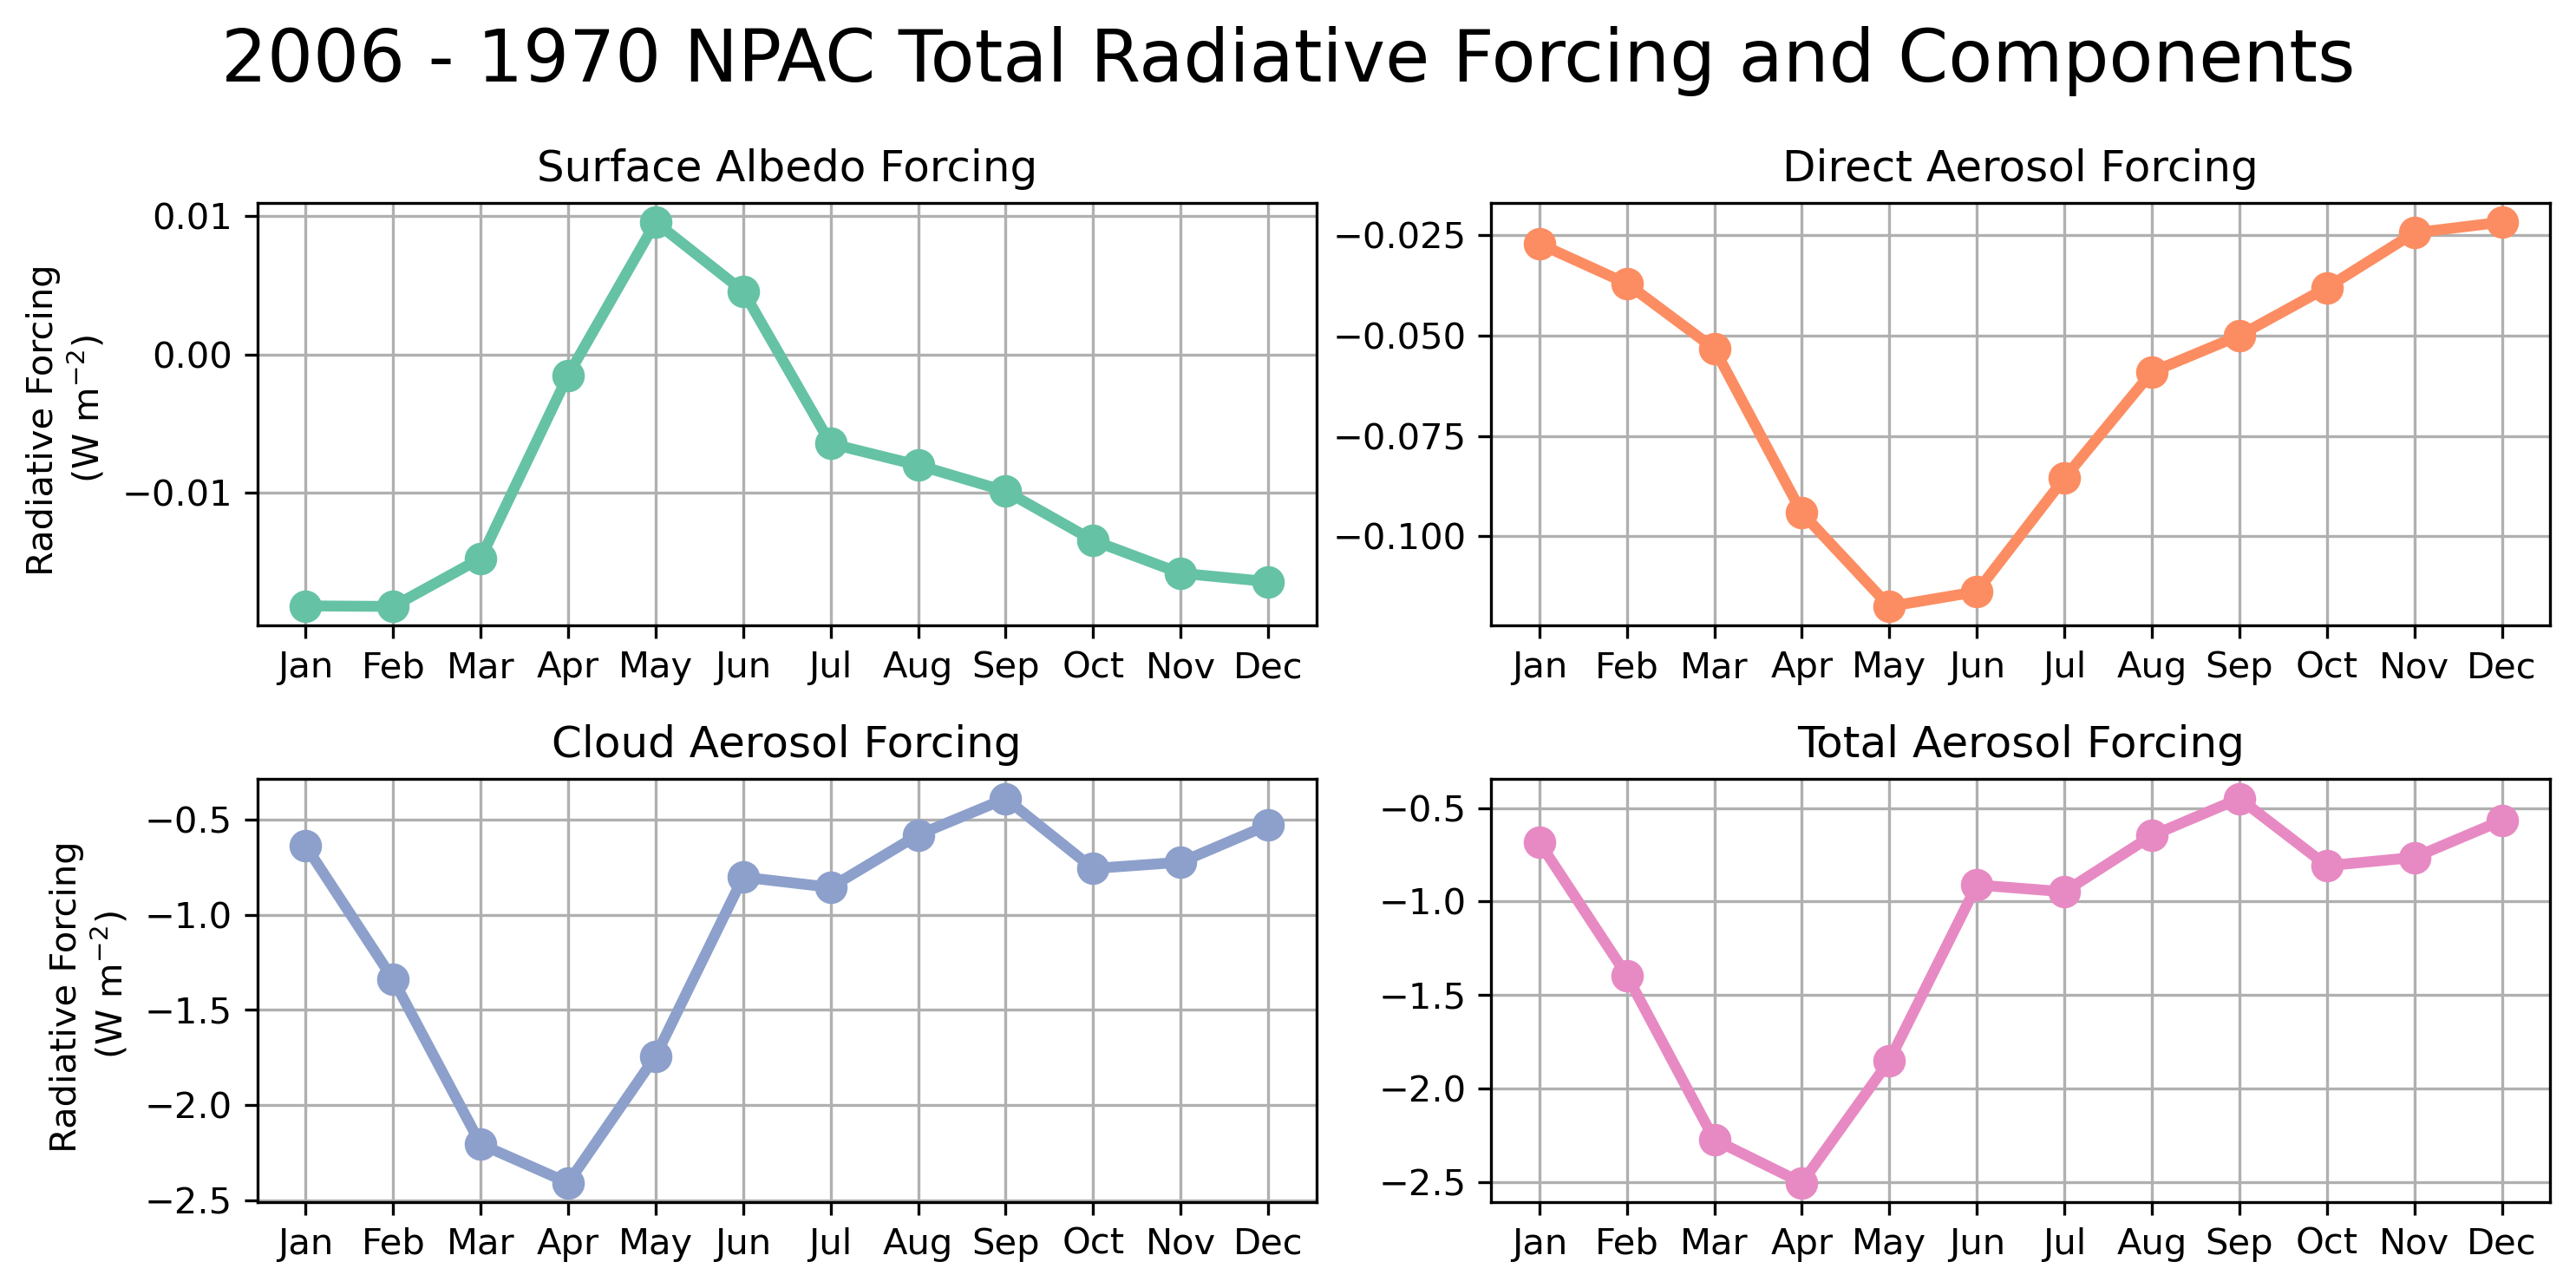

In [8]:
import calendar
import seaborn as sns

months = calendar.month_abbr[1:]
color_palette = sns.color_palette("Set2")

fig, axs = plt.subplots(2,2, figsize=(10,5), dpi=300)

axs[0,0].plot(months, albedo_forcing_climo.roll(month=-1), marker='o', markersize=8, color=color_palette[0], lw=3)
axs[0,0].set_ylabel('Radiative Forcing \n (W m$^{-2}$)')
axs[0,0].set_title('Surface Albedo Forcing')
axs[0,0].grid()
axs[0,1].plot(months, direct_forcing_climo.roll(month=-1), marker='o', markersize=8, color=color_palette[1], lw=3)
axs[0,1].set_title('Direct Aerosol Forcing')
axs[0,1].grid()
axs[1,0].plot(months, cloud_forcing_climo.roll(month=-1), marker='o', markersize=8, color=color_palette[2], lw=3)
axs[1,0].set_ylabel('Radiative Forcing \n (W m$^{-2}$)')
axs[1,0].set_title('Cloud Aerosol Forcing')
axs[1,0].grid()
axs[1,1].plot(months, total_forcing_climo.roll(month=-1), marker='o', markersize=8, color=color_palette[3], lw=3)
axs[1,1].set_title('Total Aerosol Forcing')
axs[1,1].grid()

fig.suptitle('2006 - 1970 NPAC Total Radiative Forcing and Components', fontsize=20)
plt.tight_layout()

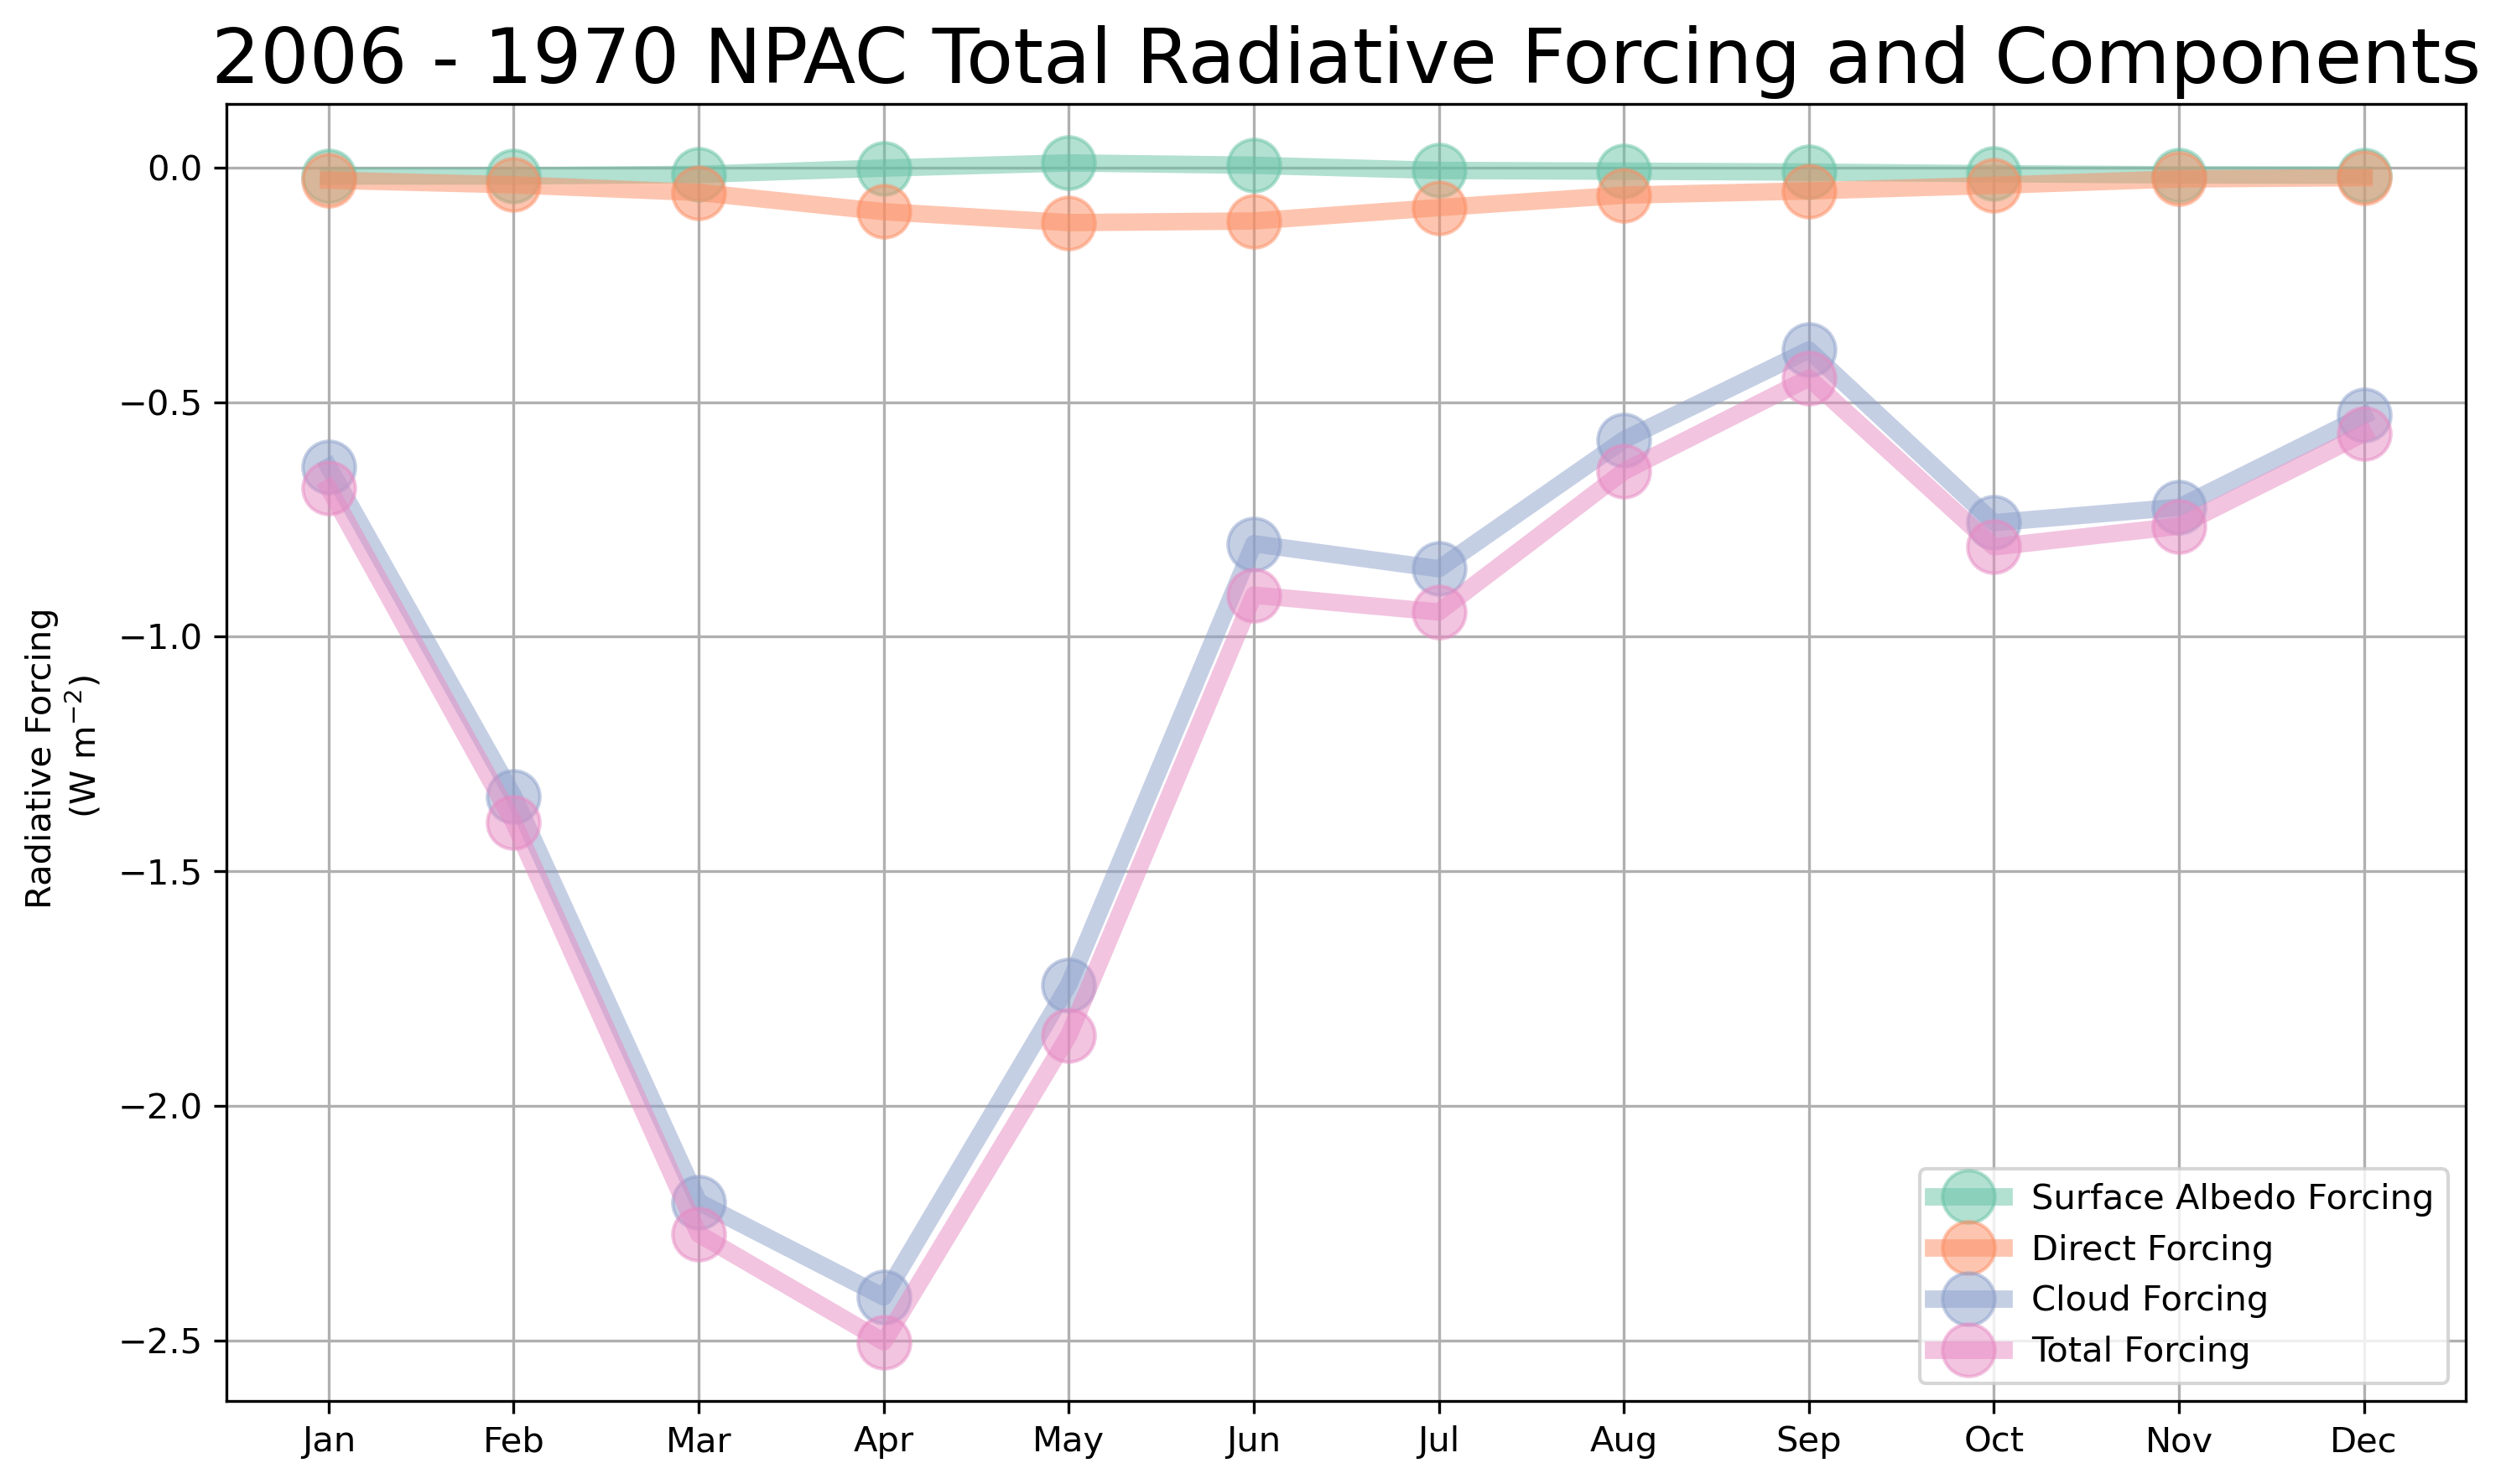

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6), dpi=300)  # Optional: adjust size to make it look nice at high DPI

plt.plot(months, albedo_forcing_climo.roll(month=-1), marker='o', markersize=15, lw=5, alpha=0.5, label='Surface Albedo Forcing', color=color_palette[0])
plt.plot(months, direct_forcing_climo.roll(month=-1), marker='o', markersize=15, lw=5, alpha=0.5, label='Direct Forcing', color=color_palette[1])
plt.plot(months, cloud_forcing_climo.roll(month=-1), marker='o', markersize=15, lw=5, alpha=0.5, label='Cloud Forcing', color=color_palette[2])
plt.plot(months, total_forcing_climo.roll(month=-1), marker='o', markersize=15, lw=5, alpha=0.5, label='Total Forcing', color=color_palette[3])

plt.grid()
plt.ylabel('Radiative Forcing \n (W m$^{-2}$)')
plt.title('2006 - 1970 NPAC Total Radiative Forcing and Components', fontsize=22)
plt.legend()

plt.tight_layout()  # Makes sure labels and titles don't get cut off
plt.show()  # Show it on screen as usual

/glade/derecho/scratch/jzweifel/tmp/ipykernel_72775/2357807304.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


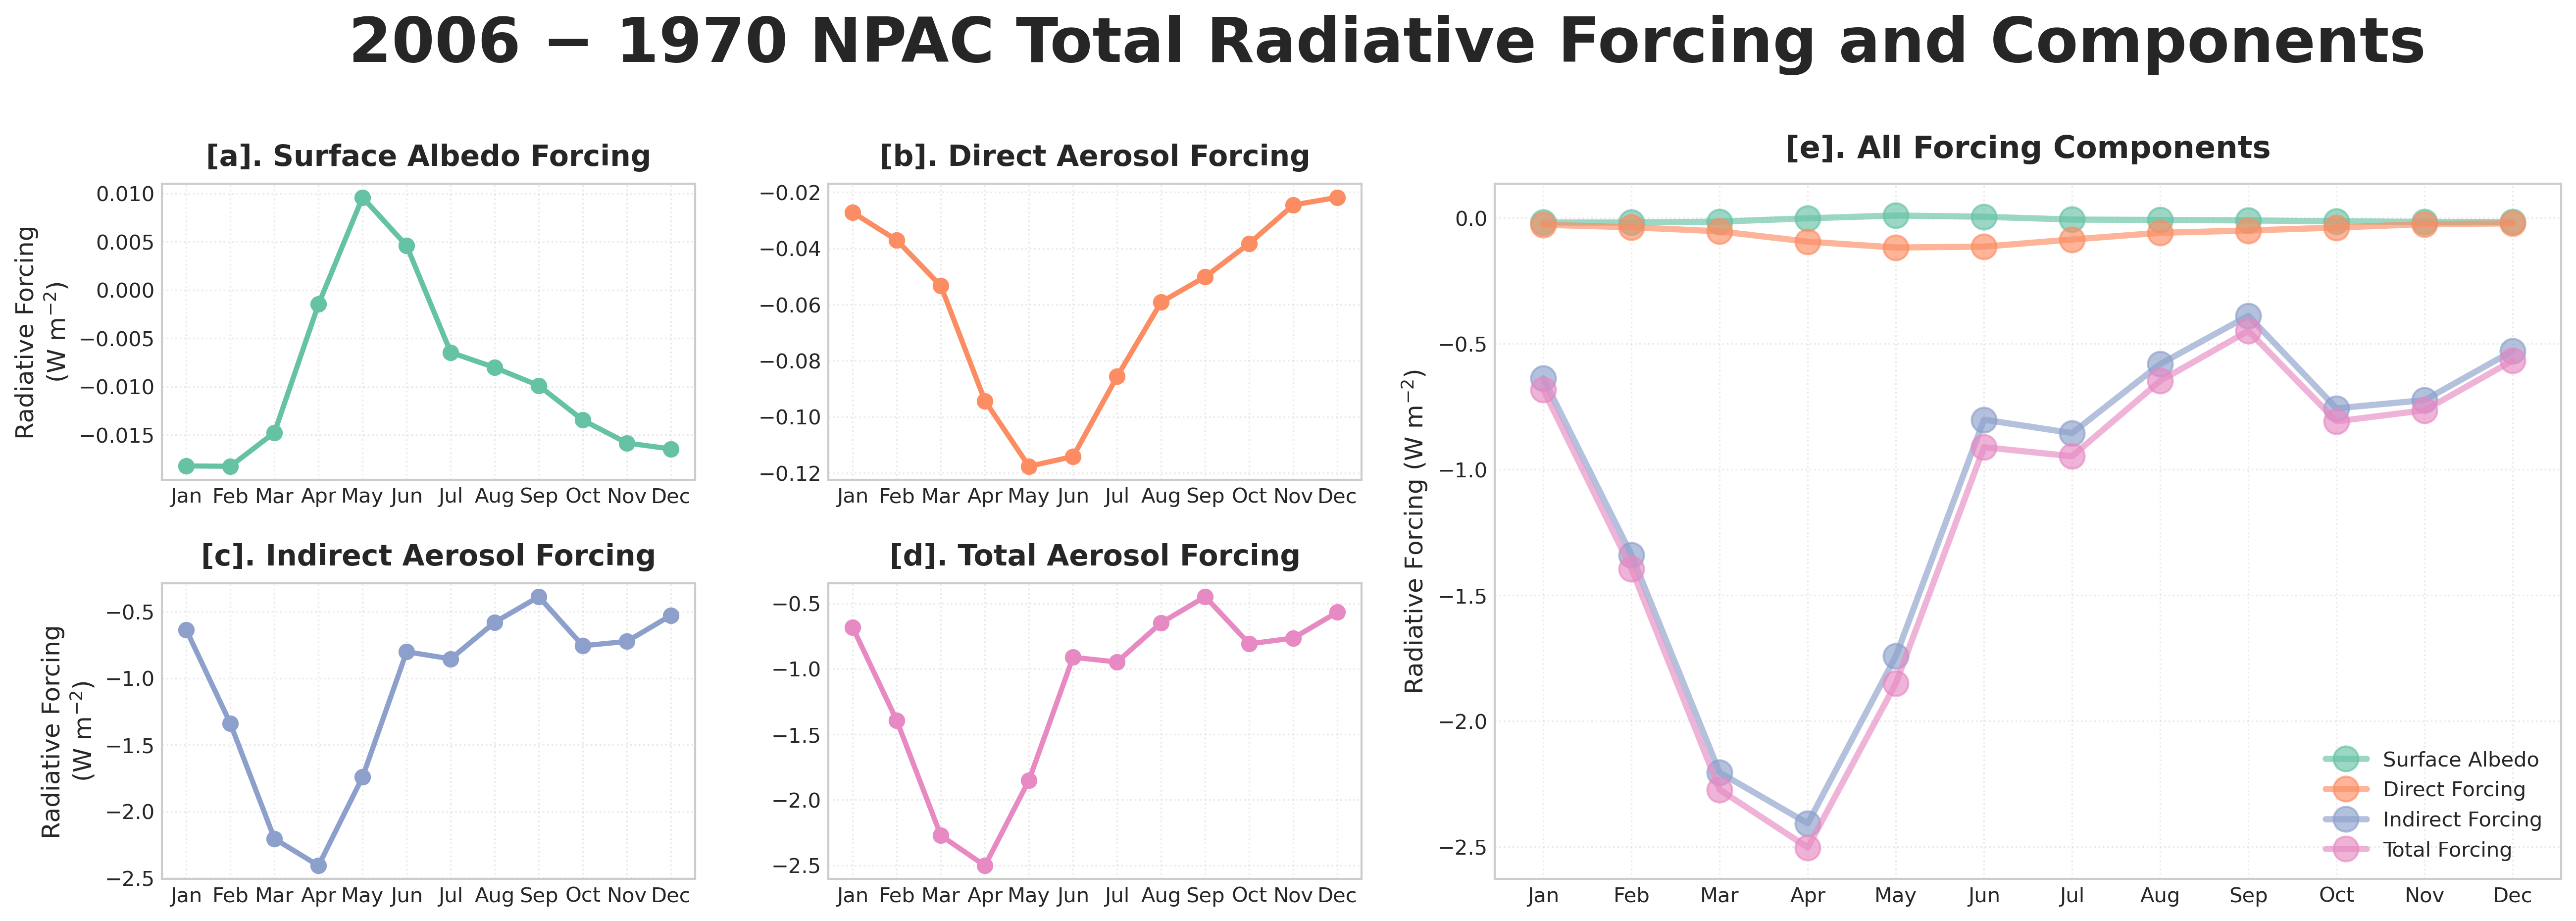

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

# ---------------------------------------------------------
# Global styling (matches all your polished figures)
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'legend.frameon': False,
    'lines.linewidth': 2.5,
    'axes.titleweight': 'bold',
    'axes.grid': True
})

months = calendar.month_abbr[1:]
color_palette = sns.color_palette("Set2")

# ---------------------------------------------------------
# Create unified figure with 50:50 split
# ---------------------------------------------------------
fig = plt.figure(figsize=(22, 6), dpi=300)

# Left block = 2 columns, Right block = 2 columns → 50/50
gs = fig.add_gridspec(
    2, 4, 
    width_ratios=[1, 1, 2, 0],    # last zero column is unused; keeps spacing cleaner
    wspace=0.25,
    hspace=0.35                   # <-- increased to fix overlapping titles
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

# Overlay spans both rows but uses columns 2–3
ax_big = fig.add_subplot(gs[:,2])

# =========================================================
# 2×2 COMPONENT PANELS (left side)
# =========================================================

# ---- Panel 1 ----
ax1.plot(months, albedo_forcing_climo.roll(month=-1),
         marker='o', markersize=7, lw=2.5, color=color_palette[0])
ax1.set_title("[a]. Surface Albedo Forcing", fontsize=14, y=1.02)
ax1.set_ylabel("Radiative Forcing\n(W m$^{-2}$)", fontsize=12)
ax1.grid(linestyle=":", alpha=0.4)

# ---- Panel 2 ----
ax2.plot(months, direct_forcing_climo.roll(month=-1),
         marker='o', markersize=7, lw=2.5, color=color_palette[1])
ax2.set_title("[b]. Direct Aerosol Forcing", fontsize=14, y=1.02)
ax2.grid(linestyle=":", alpha=0.4)

# ---- Panel 3 ----
ax3.plot(months, cloud_forcing_climo.roll(month=-1),
         marker='o', markersize=7, lw=2.5, color=color_palette[2])
ax3.set_title("[c]. Indirect Aerosol Forcing", fontsize=14, y=1.02)  # lifted
ax3.set_ylabel("Radiative Forcing\n(W m$^{-2}$)", fontsize=12)
ax3.grid(linestyle=":", alpha=0.4)

# ---- Panel 4 ----
ax4.plot(months, total_forcing_climo.roll(month=-1),
         marker='o', markersize=7, lw=2.5, color=color_palette[3])
ax4.set_title("[d]. Total Aerosol Forcing", fontsize=14, y=1.02)
ax4.grid(linestyle=":", alpha=0.4)

# =========================================================
# BIG OVERLAY PANEL (right side, 50% of entire figure)
# =========================================================

ax_big.plot(months, albedo_forcing_climo.roll(month=-1),
            marker='o', markersize=12, lw=3, alpha=0.65,
            label='Surface Albedo', color=color_palette[0])

ax_big.plot(months, direct_forcing_climo.roll(month=-1),
            marker='o', markersize=12, lw=3, alpha=0.65,
            label='Direct Forcing', color=color_palette[1])

ax_big.plot(months, cloud_forcing_climo.roll(month=-1),
            marker='o', markersize=12, lw=3, alpha=0.65,
            label='Indirect Forcing', color=color_palette[2])

ax_big.plot(months, total_forcing_climo.roll(month=-1),
            marker='o', markersize=12, lw=3, alpha=0.65,
            label='Total Forcing', color=color_palette[3])

ax_big.set_title("[e]. All Forcing Components", fontsize=15, y=1.02)
ax_big.set_ylabel("Radiative Forcing (W m$^{-2}$)", fontsize=12)
ax_big.grid(linestyle=":", alpha=0.4)
ax_big.legend(fontsize=10, loc="lower right")

# ---------------------------------------------------------
# Suptitle
# ---------------------------------------------------------
fig.suptitle("2006 − 1970 NPAC Total Radiative Forcing and Components",
             fontsize=30, weight='bold', y=1.08)

plt.tight_layout()
plt.subplots_adjust(top=0.89)
plt.show()